# 04 — Sensibilidad hipotética de costos en validation

Este notebook reproduce escenarios **hipotéticos, no aprobados** de decisión binaria BMR frente al umbral fijo 0,5. Lee únicamente `data/interim/validation_scores.parquet`, generado por el notebook 03. No reentrena, no lee los CSV raw y no carga ni puntúa `test`.

## Supuestos explícitos

- Unidad: unidad registrada en `TransactionAmt`; no se etiqueta USD porque falta confirmar la fuente.
- `λ ∈ {0,25; 0,50; 1,00}`: fracción hipotética de pérdida si se aprueba fraude.
- `B ∈ {0,25; 0,50; 1,00; 2,00}` veces la mediana del monto de validation (sin usar etiquetas) como costo hipotético de bloquear una legítima.
- `C_block_fraud = 0`: supuesto idealizado de prevención completa, no hecho observado.
- Revisión y árbol sensibles al costo están fuera de esta sensibilidad.

La tabla mide costo proxy realizado sobre las mismas observaciones usadas para revisar los resultados de validation. Sirve para sensibilidad exploratoria; no representa ahorro real ni estimación independiente fuera de muestra. El gate de costos aprobados de notebook 03 y el gate de test no se modifican.

## 1. Cargar scores y validar alcance

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "interim").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Abra Jupyter desde el repositorio o una subcarpeta")


PROJECT_ROOT = find_project_root()
SCORES_PATH = PROJECT_ROOT / "data" / "interim" / "validation_scores.parquet"
TABLE_PATH = PROJECT_ROOT / "results" / "tables" / "escenarios_hipoteticos_validation.csv"
FIGURE_PATH = PROJECT_ROOT / "results" / "figures" / "ahorro_hipotetico_validation.png"
if not SCORES_PATH.exists():
    raise FileNotFoundError(f"No existe {SCORES_PATH}; ejecute notebook 03 hasta métricas predictivas")

scores = pd.read_parquet(SCORES_PATH)
required_columns = {
    "TransactionAmt", "isFraud", "probability_calibrated", "action_fixed_0_5"
}
missing_columns = required_columns.difference(scores.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas: {sorted(missing_columns)}")
if scores[list(required_columns)].isna().any().any():
    raise ValueError("Hay valores nulos en las columnas requeridas")
if not np.isin(scores["isFraud"].to_numpy(), (0, 1)).all():
    raise ValueError("isFraud debe contener solo 0/1")
if not scores["action_fixed_0_5"].astype(str).isin(["approve", "block"]).all():
    raise ValueError("action_fixed_0_5 debe contener approve/block")

amount = scores["TransactionAmt"].to_numpy(dtype=float)
y = scores["isFraud"].to_numpy(dtype=int)
p = np.clip(scores["probability_calibrated"].to_numpy(dtype=float), 0, 1)
action_fixed = scores["action_fixed_0_5"].astype(str).to_numpy()
if not np.isfinite(amount).all() or (amount < 0).any():
    raise ValueError("TransactionAmt debe ser finito y no negativo")
if not np.isfinite(p).all():
    raise ValueError("Las probabilidades calibradas deben ser finitas")

reference_amount = float(np.median(amount))  # sin usar etiquetas para fijar la escala hipotética
print(f"Filas validation: {len(scores):,}; fraudes: {int(y.sum()):,}; mediana monto: {reference_amount:.4f} unidades")
print("No se cargó test ni se volvió a entrenar el modelo.")

Filas validation: 42,047; fraudes: 1,517; mediana monto: 65.0000 unidades
No se cargó test ni se volvió a entrenar el modelo.


## 2. Evaluar la cuadrícula de escenarios

In [2]:
LAMBDA_GRID = (0.25, 0.50, 1.00)
B_RATIO_GRID = (0.25, 0.50, 1.00, 2.00)
FRAUD_BLOCK_RESIDUAL_COST = 0.0
SCENARIO_STATUS = "HIPOTETICO_NO_APROBADO"

fraud = y == 1
legitimate = ~fraud
rows = []
for loss_fraction in LAMBDA_GRID:
    for b_ratio in B_RATIO_GRID:
        legitimate_block_cost = b_ratio * reference_amount
        risk_approve = p * loss_fraction * amount
        risk_block = (1 - p) * legitimate_block_cost + p * FRAUD_BLOCK_RESIDUAL_COST
        action_bmr = np.where(risk_approve <= risk_block, "approve", "block")
        for strategy, actions in (("fixed_0_5", action_fixed), ("bmr_binary", action_bmr)):
            blocked = actions == "block"
            realized_cost = np.zeros(len(y), dtype=float)
            realized_cost[fraud & ~blocked] = loss_fraction * amount[fraud & ~blocked]
            realized_cost[fraud & blocked] = FRAUD_BLOCK_RESIDUAL_COST
            realized_cost[legitimate & blocked] = legitimate_block_cost
            rows.append({
                "scenario_status": SCENARIO_STATUS,
                "strategy": strategy,
                "rows": len(y),
                "frauds": int(fraud.sum()),
                "loss_fraction_lambda": loss_fraction,
                "legitimate_block_cost_ratio_of_validation_median_amount": b_ratio,
                "validation_median_amount_reference": reference_amount,
                "legitimate_block_cost_B_proxy": legitimate_block_cost,
                "fraud_block_residual_cost_C_proxy": FRAUD_BLOCK_RESIDUAL_COST,
                "review_enabled": False,
                "cost_total_proxy": float(realized_cost.sum()),
                "cost_per_transaction_proxy": float(realized_cost.mean()),
                "frauds_blocked": int(np.sum(fraud & blocked)),
                "frauds_missed": int(np.sum(fraud & ~blocked)),
                "fraud_recall": float(np.sum(fraud & blocked) / fraud.sum()),
                "legitimate_block_count": int(np.sum(legitimate & blocked)),
                "legitimate_block_rate": float(np.mean(blocked[legitimate])),
                "policy_block_count": int(blocked.sum()),
            })

scenario_results = pd.DataFrame(rows)
fixed_cost_by_scenario = (
    scenario_results[scenario_results["strategy"].eq("fixed_0_5")]
    .set_index(["loss_fraction_lambda", "legitimate_block_cost_ratio_of_validation_median_amount"])["cost_total_proxy"]
)
scenario_keys = list(zip(
    scenario_results["loss_fraction_lambda"],
    scenario_results["legitimate_block_cost_ratio_of_validation_median_amount"],
))
scenario_results["fixed_baseline_cost_proxy"] = [fixed_cost_by_scenario.loc[key] for key in scenario_keys]
scenario_results["savings_vs_fixed_proxy"] = (
    scenario_results["fixed_baseline_cost_proxy"] - scenario_results["cost_total_proxy"]
)
scenario_results["savings_fraction_vs_fixed_proxy"] = np.where(
    scenario_results["fixed_baseline_cost_proxy"] > 0,
    scenario_results["savings_vs_fixed_proxy"] / scenario_results["fixed_baseline_cost_proxy"],
    np.nan,
)

bmr_results = scenario_results[scenario_results["strategy"].eq("bmr_binary")].copy()
print(f"Escenarios BMR: {len(bmr_results)}; todos marcados como {SCENARIO_STATUS}.")
display(bmr_results[[
    "loss_fraction_lambda",
    "legitimate_block_cost_ratio_of_validation_median_amount",
    "legitimate_block_cost_B_proxy",
    "cost_total_proxy", "fixed_baseline_cost_proxy",
    "savings_vs_fixed_proxy", "savings_fraction_vs_fixed_proxy",
    "fraud_recall", "legitimate_block_rate",
]])

Escenarios BMR: 12; todos marcados como HIPOTETICO_NO_APROBADO.


,loss_fraction_lambda,legitimate_block_cost_ratio_of_validation_median_amount,legitimate_block_cost_B_proxy,cost_total_proxy,fixed_baseline_cost_proxy,savings_vs_fixed_proxy,savings_fraction_vs_fixed_proxy,fraud_recall,legitimate_block_rate
1,0.25,0.25,16.25,39000.79675,52322.302,13321.50525,0.254605,0.321028,0.009499
3,0.25,0.50,32.50,44176.49150,54402.302,10225.81050,0.187967,0.261701,0.004466
5,0.25,1.00,65.00,50073.78900,58562.302,8488.51300,0.144948,0.201714,0.002048
7,0.25,2.00,130.00,56890.25075,66882.302,9992.05125,0.149398,0.136454,0.001036
9,0.50,0.25,16.25,60685.19050,102564.604,41879.41350,0.408322,0.404087,0.020923
11,0.50,0.50,32.50,78001.59350,104644.604,26643.01050,0.254605,0.321028,0.009499
13,0.50,1.00,65.00,88352.98300,108804.604,20451.62100,0.187967,0.261701,0.004466
15,0.50,2.00,130.00,100147.57800,117124.604,16977.02600,0.144948,0.201714,0.002048
17,1.00,0.25,16.25,95654.01000,203049.208,107395.19800,0.528912,0.508240,0.044115
19,1.00,0.50,32.50,121370.38100,205129.208,83758.82700,0.408322,0.404087,0.020923


## 3. Guardar tabla y gráfica

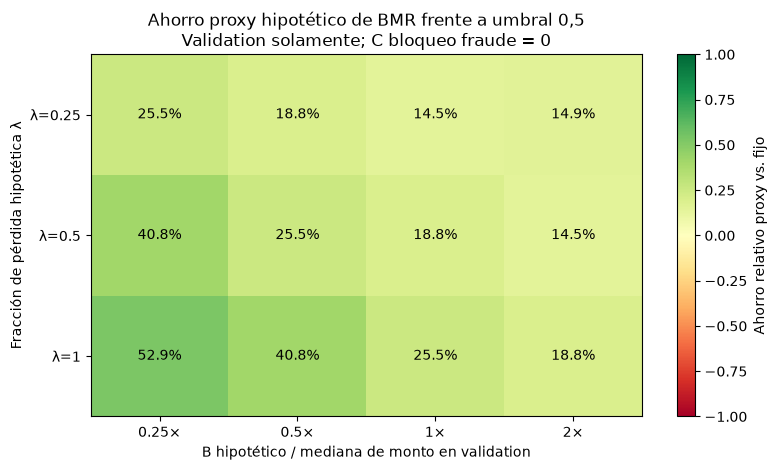

Tabla guardada: C:\Users\USUARIO\Desktop\Universidad\Ing de sistemas\Proyecto integrador 2\IEEE-CIS-Fraud-Detection-PI2\results\tables\escenarios_hipoteticos_validation.csv
Figura guardada: C:\Users\USUARIO\Desktop\Universidad\Ing de sistemas\Proyecto integrador 2\IEEE-CIS-Fraud-Detection-PI2\results\figures\ahorro_hipotetico_validation.png


In [3]:
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
scenario_results.to_csv(TABLE_PATH, index=False)

savings = (
    bmr_results.pivot(
        index="loss_fraction_lambda",
        columns="legitimate_block_cost_ratio_of_validation_median_amount",
        values="savings_fraction_vs_fixed_proxy",
    ).sort_index()
)
fig, ax = plt.subplots(figsize=(8, 4.8))
image = ax.imshow(savings.to_numpy(), cmap="RdYlGn", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(savings.columns)), [f"{x:g}×" for x in savings.columns])
ax.set_yticks(range(len(savings.index)), [f"λ={x:g}" for x in savings.index])
ax.set_xlabel("B hipotético / mediana de monto en validation")
ax.set_ylabel("Fracción de pérdida hipotética λ")
ax.set_title("Ahorro proxy hipotético de BMR frente a umbral 0,5\nValidation solamente; C bloqueo fraude = 0")
for i in range(savings.shape[0]):
    for j in range(savings.shape[1]):
        ax.text(j, i, f"{savings.iloc[i, j]:.1%}", ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, label="Ahorro relativo proxy vs. fijo")
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Tabla guardada: {TABLE_PATH}")
print(f"Figura guardada: {FIGURE_PATH}")

## 4. Interpretación y límites

El ahorro relativo de cada escenario es `(costo_fijo - costo_BMR) / costo_fijo`, solo si el costo fijo es positivo. El recall y la tasa de legítimas bloqueadas muestran el intercambio operativo de cada regla.

No interprete estos valores como ahorro financiero real: dependen de supuestos hipotéticos y se miden sobre las mismas filas de validation usadas para inspeccionar el modelo. La unidad de monto aún no está confirmada. Este notebook no modifica `COST_CONFIG`, no aprueba parámetros, no evalúa revisión ni el árbol y no abre el gate de test.

Para un resultado final se requieren costos sustentados/aprobados, una política congelada y una sola evaluación en test.